In [196]:
import numpy as np
import matplotlib.pyplot as plt
from operator import itemgetter

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [154]:
from scipy.stats import binned_statistic_2d
from astropy.convolution import convolve, Gaussian2DKernel

t_min = -1
t_max = 1
n_t = 64
counts_min = 100
counts_max = 100
fwhm_psf = 0.1
pixel_size = (t_max - t_min) / n_t

bins = np.linspace(t_min, t_max, n_t + 1)

sigma_psf = fwhm_psf / 2 ** 1.5 * np.sqrt(np.log(2))  # Convert FWHM to standard deviation
kernel = Gaussian2DKernel(x_stddev=1.0 * sigma_psf / pixel_size)

def simulate(plot=False, poiss_fluc=True):
    
    mu_iso = np.random.uniform(0, 50)
    z_n_mu = np.random.uniform(0, 100)
    z_n = np.random.poisson(z_n_mu)
            
    z_x = np.random.uniform(t_min, t_max, size=(2, z_n))
    z_c = np.random.uniform(counts_min, counts_max, z_n)

    mu_bkg = mu_iso * np.ones((n_t, n_t))

    if z_n > 0:
        mu_signal = binned_statistic_2d(x=z_x[0], y=z_x[1], values=z_c, statistic='sum', bins=bins).statistic
        counts_binned = (mu_bkg + convolve(mu_signal, kernel))
    else:
        counts_binned = (mu_bkg)

    if poiss_fluc:
        counts_binned = np.random.poisson(counts_binned)

    if plot:
        plt.imshow(counts_binned)
    
    return z_n_mu, mu_iso, counts_binned

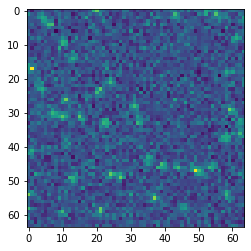

In [201]:
_, _, x = simulate(plot=True)

In [202]:
from scipy import stats

def power_spectrum(x):
    
    npix = x.shape[0]

    fourier_image = np.fft.fftn(x)
    fourier_amplitudes = np.abs(fourier_image)**2

    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)

    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()

    kbins = np.arange(0.5, npix//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic = "mean",
                                         bins = kbins)
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    return Abins

In [203]:
simulations = [simulate() for _ in range(20000)]
x = list(map(itemgetter(2), simulations))
mu_z_n = list(map(itemgetter(0), simulations))
mu_iso = list(map(itemgetter(1), simulations))
x_f = np.array([power_spectrum(x_i) for x_i in x])

Text(0.5, 1.0, 'Mean power spectrum')

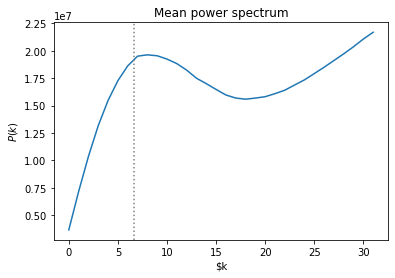

In [234]:
plt.plot(np.mean(x_f, axis=0))
plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)

plt.xlabel("$k")
plt.ylabel("$P(k)$")
plt.title("Mean power spectrum")

In [236]:
from sklearn.metrics import mutual_info_score

def calc_MI(x, y, bins):
    c_xy = np.histogram2d(x, y, bins)[0]
    mi = mutual_info_score(None, None, contingency=c_xy)
    return mi

Text(0, 0.5, 'MI')

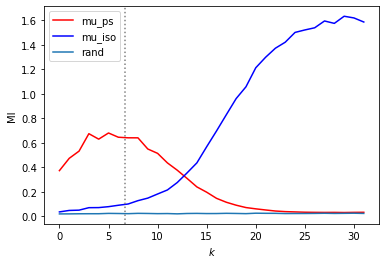

In [238]:
n_bins = 32

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(mu_z_n, x_f[:, i], n_bins))
    
plt.plot(MI, label="mu_ps", color='red')

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(x_f[:, i], mu_iso, n_bins))
    
plt.plot(MI, label="mu_iso", color='blue')

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(x_f[:, i], np.random.uniform(0, 3, size=x_f[:, i].shape), n_bins))
    
plt.plot(MI, label="rand")

plt.legend()

plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)

plt.xlabel("$k$")
plt.ylabel("MI")

# Lightning

In [239]:
import sys
sys.path.append("../")
from models.resnet import ResNetEstimator

In [240]:
import torch
import torch.nn as nn

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, StochasticWeightAveraging
from pytorch_lightning.loggers import MLFlowLogger

from torch.utils.data import TensorDataset, DataLoader, random_split, SubsetRandomSampler

In [316]:
class ResNetRegressor(pl.LightningModule):
    def __init__(self, n_out=2):
        super().__init__()
        
        self.save_hyperparameters()
        
        self.resnet = ResNetEstimator(cfg=18, n_out=n_out, log_input=False)
        self.loss = nn.MSELoss()
        
    def forward(self, x):
        x = self.resnet(x)
        return x
        
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=1e-3, weight_decay=1e-4)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        out = self(x)     
        loss = self.loss(y, out)
        self.log('train_loss', loss.mean(), on_epoch=True)
                
        return loss.mean()
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        out = self(x)     
        loss = self.loss(y, out)
        self.log('val_loss', loss.mean(), on_epoch=True)
        return loss.mean()

In [317]:
val_fraction = 0.1
n_samples_val = int(val_fraction * len(x))

y = torch.Tensor(np.array([mu_z_n, mu_iso])).T
y_std = y.std(axis=0)
y_mean = y.mean(axis=0)
y = (y - y_mean) / y_std

x = torch.Tensor(x)

dataset = TensorDataset(x, y)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=64, num_workers=16, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=64, num_workers=16, shuffle=False)

/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/torch/utils/data/dataloader.py:478: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [318]:
pl.utilities.seed.seed_everything(seed=np.random.randint(638))  # Set universal seed

model = ResNetRegressor()

Global seed set to 148


In [324]:
checkpoint_callback = ModelCheckpoint(monitor="val_loss")
trainer = pl.Trainer(max_epochs=10, gpus=1, gradient_clip_val=0.2, callbacks=[checkpoint_callback,],)
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)
model.load_from_checkpoint(checkpoint_callback.best_model_path);

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Set SLURM handle signals.

  | Name   | Type            | Params
-------------------------------------------
0 | resnet | ResNetEstimator | 12.2 M
1 | loss   | MSELoss         | 0     
-------------------------------------------
12.2 M    Trainable params
0         Non-trainable params
12.2 M    Total params
48.900    Total estimated model params size (MB)


Validation sanity check: 0it [00:00, ?it/s]

/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/torch/utils/data/dataloader.py:478: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
Global seed set to 148


Training: -1it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

In [325]:
simulations_test = [simulate() for _ in range(20000)]
x_test = list(map(itemgetter(2), simulations_test))
mu_z_n_test = list(map(itemgetter(0), simulations_test))
mu_iso_test = list(map(itemgetter(1), simulations_test))
x_f_test = np.array([power_spectrum(x_i) for x_i in x_test])

In [326]:
y_test =  torch.Tensor(np.array([mu_z_n_test, mu_iso_test])).T
y_test = (y_test - y_mean) / y_std

In [327]:
x_test = torch.Tensor(x_test)

In [328]:
dataset_test = TensorDataset(x_test, y_test)
test_loader = DataLoader(dataset_test, batch_size=256, num_workers=1, shuffle=False)

In [329]:
mu_z_n_test, mu_iso_test = y_test.detach().numpy().T

In [330]:
from tqdm.notebook import tqdm

In [331]:
model.to('cuda')

mu_pred = []
for batch in tqdm(test_loader):
    with torch.no_grad():
        x_b, y_b = batch
        mu_pred.append(model(x_b.to('cuda')).cpu())
    del x_b

  0%|          | 0/79 [00:00<?, ?it/s]

In [332]:
mu_z_n_pred, mu_iso_pred = torch.cat(mu_pred).detach().numpy().T

Text(0, 0.5, '$\\mu_{ps, pred}$')

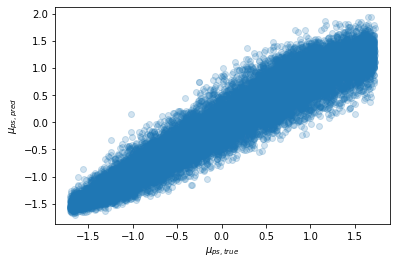

In [345]:
plt.scatter(mu_z_n_test, mu_z_n_pred, alpha=0.2)
plt.xlabel(r"$\mu_{ps, true}$")
plt.ylabel(r"$\mu_{ps, pred}$")

Text(0, 0.5, '$\\mu_{iso, pred}$')

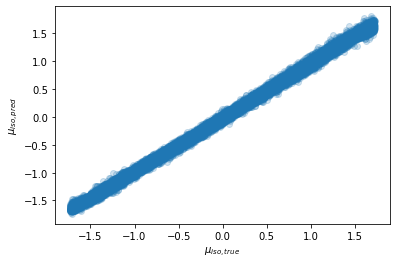

In [346]:
plt.scatter(mu_iso_test, mu_iso_pred, alpha=0.2)
plt.xlabel(r"$\mu_{iso, true}$")
plt.ylabel(r"$\mu_{iso, pred}$")

Text(0, 0.5, 'MI')

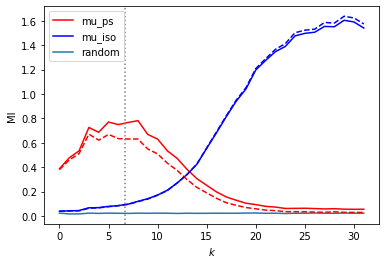

In [348]:
n_bins = 32

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(mu_z_n_pred, x_f_test[:, i], n_bins))
    
plt.plot(MI, label="mu_ps", color='red')

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(x_f_test[:, i], mu_iso_pred, n_bins))
    
plt.plot(MI, label="mu_iso", color='blue')

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(x_f_test[:, i], np.random.uniform(0, 3, size=x_f_test[:, i].shape), n_bins))
    
plt.plot(MI, label="random")

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(mu_z_n_test, x_f_test[:, i], n_bins))
    
plt.plot(MI, color='red', ls='--')

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(x_f_test[:, i], mu_iso_test, n_bins))
    
plt.plot(MI, color='blue', ls='--')

plt.legend()

plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)

plt.xlabel("$k$")
plt.ylabel("MI")